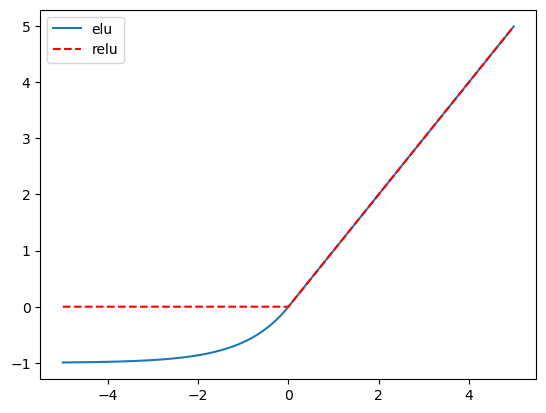

In [1]:
# 오토인코더 => 입력데이터 복제를 위해 훈련되는 딥러닝

# sigmoid, relu, elu
import math
import matplotlib.pyplot as plt
import numpy as np

# -5 ~ 5 까지 0.01 단위로 생성
x = np.arange(-5, 5, 0.01)
relu = [0 if z<0 else z for z in x]
elu = [1.0 * (np.exp(z)-1) if z<0 else z for z in x]

plt.plot(x, elu, label="elu")
plt.plot(x, relu, 'r--', label='relu')
plt.legend()


In [2]:
import tensorflow as tf

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [3]:
# 정규화
x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0

In [5]:
from tensorflow.keras import layers

# Dense 를 이용한 복원
model = tf.keras.Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(784, activation="elu"),
    layers.Dense(64, activation="elu"),
    layers.Dense(784, activation="sigmoid"),
    layers.Reshape((28,28))
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 716,640 (2.73 MB)

 Trainable params: 716,640 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [9]:
model.fit(x_train_scaled, x_train_scaled, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0195 - mae: 0.0544
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0098 - mae: 0.0328
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0083 - mae: 0.0294
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0074 - mae: 0.0272
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0068 - mae: 0.0257
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0062 - mae: 0.0245
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0059 - mae: 0.0236
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0056 - mae: 0.0230
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0054 - mae: 0.0224
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0051 - mae: 0.0219
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0050 - mae: 0.0216
Epoch 12/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0049 - mae: 0.0213
E

In [13]:
from sklearn.metrics import r2_score

pred = model.predict(x_test_scaled)

r2 = r2_score(
    x_test_scaled.reshape(784, -1),
    pred.reshape(784, -1)
)

r2

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.9573200701378193

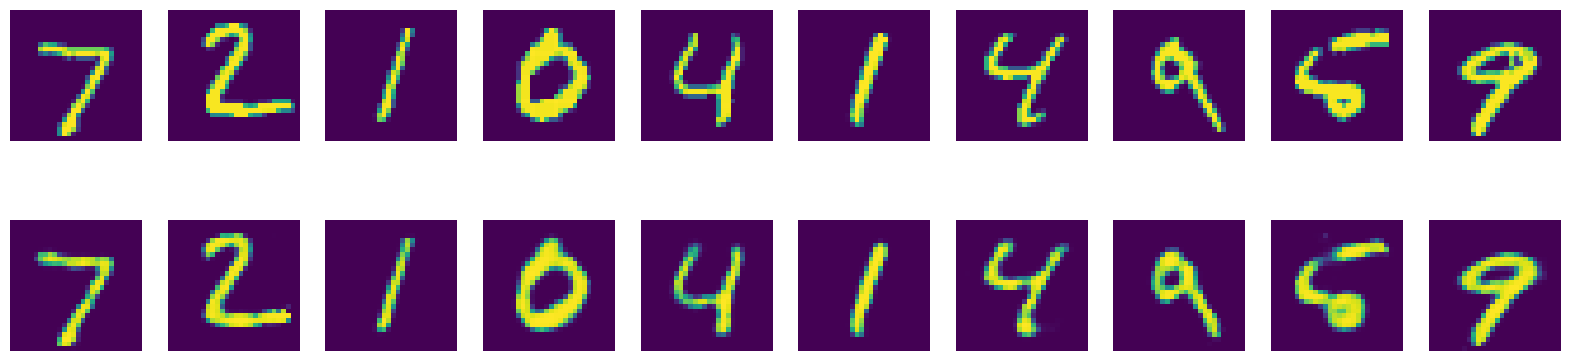

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(1, 10, (i+1))
    plt.imshow(x_test_scaled[i])
    plt.axis('off')

    plt.subplot(2, 10, (i+1+10))
    plt.imshow(pred[i])
    plt.axis('off')

plt.show()

---

In [34]:
import tensorflow as tf

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [35]:
# 정규화
x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0

In [36]:
x_train_scaled = x_train_scaled.reshape(-1, 28, 28, 1)
x_test_scaled = x_test_scaled.reshape(-1, 28, 28, 1)

x_train_scaled.shape, x_test_scaled.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [37]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Flatten, Dense, Reshape

model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(filters=32, kernel_size=(2,2), strides=(2,2), activation="elu"),
    Conv2D(filters=64, kernel_size=(2,2), strides=(2,2), activation="elu"),
    Flatten(),

    Dense(units=64, activation="elu"),

    Dense(units=7*7*64),
    Reshape(target_shape=(7,7,64)),
    Conv2DTranspose(filters=32, kernel_size=(2,2), strides=(2,2), activation="relu", padding="same"),
    Conv2DTranspose(filters=1, kernel_size=(2,2), strides=(2,2), activation="sigmoid", padding="same")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 32)     │         8,224 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │           129 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,377 (1.61 MB)

 Trainable params: 421,377 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [39]:
model.fit(x_train_scaled, x_train_scaled, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0219 - mae: 0.0527
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0105 - mae: 0.0303
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0089 - mae: 0.0272
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0080 - mae: 0.0258
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0075 - mae: 0.0248
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0072 - mae: 0.0243
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0070 - mae: 0.0237
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0069 - mae: 0.0234
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0067 - mae: 0.0230
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.0065 - mae: 0.0227
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.0064 - mae: 0.0225
Epoch 12/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0064 -

In [40]:
from sklearn.metrics import r2_score

pred = model.predict(x_test_scaled)

r2 = r2_score(
    x_test_scaled.reshape(784, -1),
    pred.reshape(784, -1)
)

r2

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


0.9634760347187519

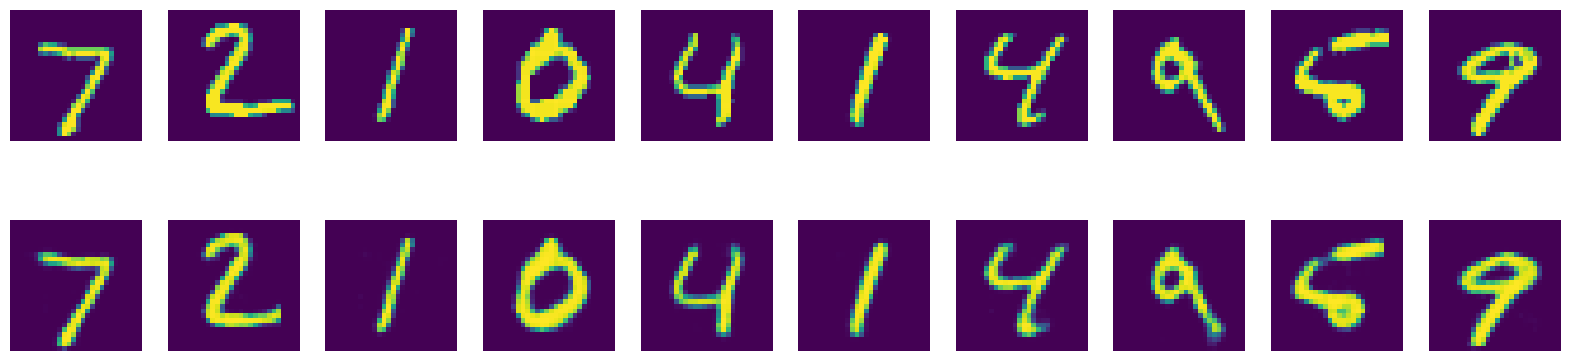

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(1, 10, (i+1))
    plt.imshow(x_test_scaled[i].reshape(28, 28))
    plt.axis('off')

    plt.subplot(2, 10, (i+1+10))
    plt.imshow(pred[i].reshape(28, 28))
    plt.axis('off')

plt.show()

---

In [42]:
import tensorflow as tf
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train.shape, x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [80]:
import numpy as np

x_train_noisy = x_train + 0.4 * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + 0.4 * tf.random.normal(shape=x_test.shape)

np.max(x_train_noisy), np.min(x_train_noisy)

(np.float32(2.8652172), np.float32(-2.2089603))

In [81]:
x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0, clip_value_max=1)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0, clip_value_max=1)

np.max(x_train_noisy), np.min(x_train_noisy)

(np.float32(1.0), np.float32(0.0))

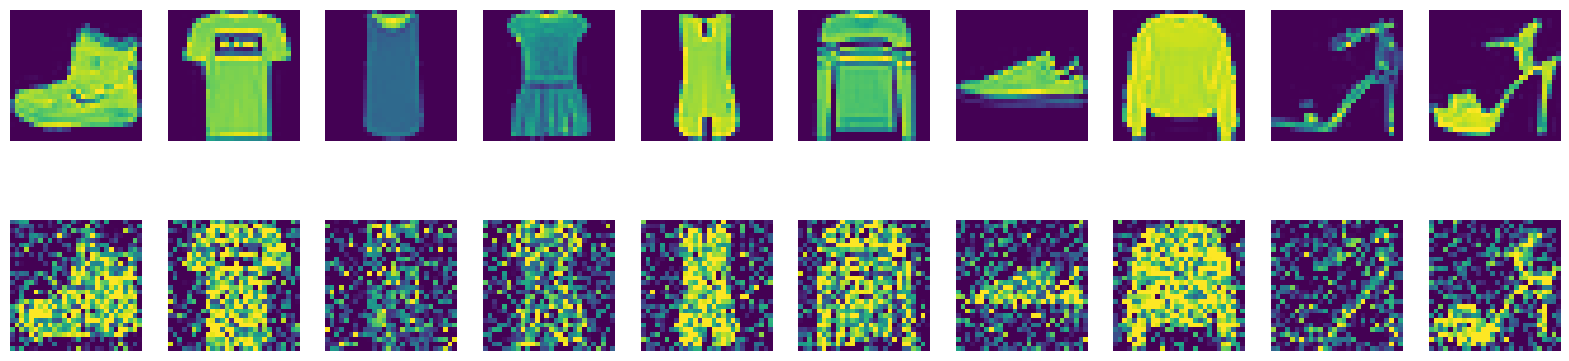

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(1, 10, (i+1))
    plt.imshow(x_train[i].reshape(28, 28))
    plt.axis('off')

    plt.subplot(2, 10, (i+1+10))
    plt.imshow(x_train_noisy[i].numpy().reshape(28, 28))
    plt.axis('off')

plt.show()

In [83]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Flatten, Dense, Reshape

model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(filters=32, kernel_size=(2,2), strides=(2,2), activation="elu", padding="same"),
    Conv2D(filters=64, kernel_size=(2,2), strides=(2,2), activation="elu", padding="same"),
    Flatten(),

    Dense(units=64, activation="elu"),

    Dense(units=7*7*64, activation="elu"),
    Reshape(target_shape=(7,7,64)),
    Conv2DTranspose(filters=32, kernel_size=(2,2), strides=(2,2), activation="relu", padding="same"),
    Conv2DTranspose(filters=1, kernel_size=(2,2), strides=(2,2), activation="sigmoid", padding="same")
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 14, 14, 32)     │         8,224 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 28, 28, 1)      │           129 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,377 (1.61 MB)

 Trainable params: 421,377 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [85]:
model.fit(x_train_noisy, x_train, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0244 - mae: 0.0901
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0161 - mae: 0.0688
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0152 - mae: 0.0661
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0148 - mae: 0.0649
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0145 - mae: 0.0640
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0142 - mae: 0.0634
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0141 - mae: 0.0628
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0139 - mae: 0.0624
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0138 - mae: 0.0620
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0136 - mae: 0.0617
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.0135 - mae: 0.0614
Epoch 12/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0134 -

In [86]:
from sklearn.metrics import r2_score

pred = model.predict(x_test_noisy)

r2 = r2_score(
    x_test.reshape(784, -1),
    pred.reshape(784, -1)
)

r2

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


0.8952125689173414

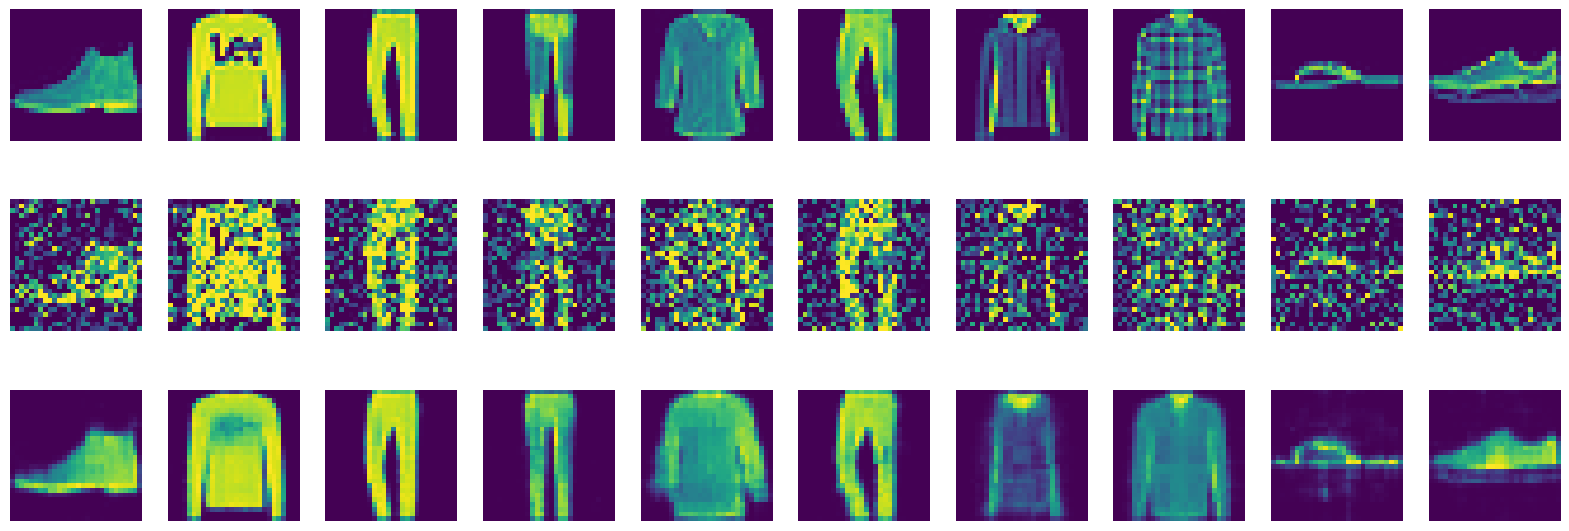

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 7))
for i in range(10):
    plt.subplot(3, 10, (i+1))
    plt.imshow(x_test[i].reshape(28, 28))
    plt.axis('off')

    plt.subplot(3, 10, (i+1+10))
    plt.imshow(x_test_noisy[i].numpy().reshape(28, 28))
    plt.axis('off')

    plt.subplot(3, 10, (i+1+20))
    plt.imshow(pred[i].reshape(28, 28))
    plt.axis('off')

plt.show()